# Real vs. Fake Job Posting Analysis  

Fake job postings damage platform trust and can lead to real financial scams. This project analyzes 17,880 job listings to identify clear patterns that separate fraudulent posts from real ones — and builds a simple risk scoring approach to flag suspicious listings before they go live.

The patterns are surprisingly simple — most fake job posts can be spotted just by checking a few key signals.

---

## Problem Statement  

- Job platforms face a growing issue with fraudulent listings that can mislead users and damage platform credibility.  
- These fake postings often look similar to real jobs, making manual detection difficult and inefficient.  
- The challenge is to identify simple, reliable signals that can help detect and flag suspicious job listings early — without slowing down legitimate employers.

---

<a id="project-introduction"></a>

## Summary & Recommendations  

- **Fake listings are ~4.8%**, but they follow clear, repeatable patterns  
- **Missing company details** is the strongest fraud signal  
- **Short or vague descriptions** are common in fake postings  
- **Certain keywords** significantly increase fraud probability  

#### Recommendation  

Implement a **Trust Score system** based on:  

- Company completeness  
- Description quality  
- Suspicious keywords  

Listings below a defined threshold → **flag for manual review before going live**

---

<a id="objective"></a>

## Business Objective  

- Fake job postings hurt both platforms and job seekers. They reduce trust, impact user retention, and can expose users to financial scams.  

- The goal of this analysis is to identify clear, data-backed signals that distinguish fraudulent job listings from real ones. 

- The focus is on using simple, clear rules that can be applied directly to catch suspicious job posts early.

---

## Dataset Overview

<a id="exploring-the-dataset"></a>

The dataset contains **17,880 job listings**, each labeled as **real (0)** or **fraudulent (1)**.  

Each row represents a job posting with key details such as:  
- Job title  
- Location  
- Company profile  
- Job description  
- Requirements and benefits  
- Employment type and experience level  

The target variable **`fraudulent`** is used to distinguish real vs fake listings.  

Some fields like salary and department are missing in many cases — which itself becomes an important signal during analysis.

### Data Dictionary

For this analysis, the most useful fields are company profile, job description, salary details, and the fraud label.

| Column | What It Tells Us |
|--------|-----------------|
| title | Job title |
| location | Where the job is based |
| department | Department or team name |
| salary_range | Pay details (when the company shared them) |
| company_profile | A short description of the company |
| description | The full job description |
| requirements | What skills or experience the job asks for |
| benefits | Any extra perks mentioned |
| telecommuting | 1 = remote work allowed, 0 = office only |
| has_company_logo | 1 = logo is there, 0 = missing |
| has_company_profile | 1 = company profile filled in, 0 = blank |
| employment_type | Full-time, Part-time, Contract, etc. |
| required_experience | Experience level the job is asking for |
| required_education | Education level required |
| industry | What kind of business or field |
| function | Type of job role (Sales, IT, Engineering, etc.) |
| fraudulent | **1 = fake post, 0 = real post** |

A few columns like salary_range and department are missing in a lot of rows — that's normal for job data since not every company fills in every field. These were cleaned up before the analysis started.

---

<a id="key-tasks"></a>

## Analytical Approach  

- Look at how many jobs are real vs fake  
- Clean important fields like description and company info  
- Compare real and fake listings to spot differences  
- Identify common patterns in fake job posts  
- Turn those patterns into simple rules   

---

<a id="tools-used"></a>

## Tools Used  

- Python (Pandas, NumPy) for data analysis  
- Matplotlib & Seaborn for visual insights  
- WordCloud for text pattern exploration  
- Jupyter Notebook for end-to-end analysis

In [1]:
# Import essential libraries for data analysis and visualization

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Plot style
sns.set(style="whitegrid")

In [2]:
# Load the CSV dataset into a pandas DataFrame
df = pd.read_csv("fake_job_postings.csv")

# Display dataset dimensions (rows, columns) and first 5 rows for inspection
print("\nDataset Overview")
print("=" * 50)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target: 'fraudulent' column (0=Real, 1=Fake)")
print("\nFirst 5 rows:")
df.head()


Dataset Overview
Shape: 17,880 rows × 18 columns
Target: 'fraudulent' column (0=Real, 1=Fake)

First 5 rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


<a id="exploring-the-dataset"></a>

## Dataset Loaded

**17,880 job listings · 18 columns** — mix of text fields (title, description, company profile) and numeric flags (logo, remote, fraud label). First look at the raw data before any cleaning.

In [3]:
print("\nDataset Structure Analysis")
print("=" * 60)
print("   • Column names & data types")
print("   • Missing values (non-null counts)")
print("   • Memory usage")
print("-" * 60)

# Display comprehensive dataset information
df.info()


Dataset Structure Analysis
   • Column names & data types
   • Missing values (non-null counts)
   • Memory usage
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      144

## Dataset Structure

Text-heavy dataset — most columns are descriptions, titles, and company info rather than clean numeric fields. The `df.info()` output shows several columns with significant gaps, especially `department`, `salary_range`, and `company_profile`. These gaps become useful later.

In [4]:
# Check missing values by column
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(df)) * 100

# Combine into DataFrame (only columns with missing data)
missing_df = pd.DataFrame({
    'Missing Values': missing_data, 
    'Percent (%)': missing_percent
})
missing_df = missing_df[missing_df['Missing Values'] > 0]

# Display top 10 missing columns
print("Top Missing Values:")
missing_df.head(10)

Top Missing Values:


,Missing Values,Percent (%)
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


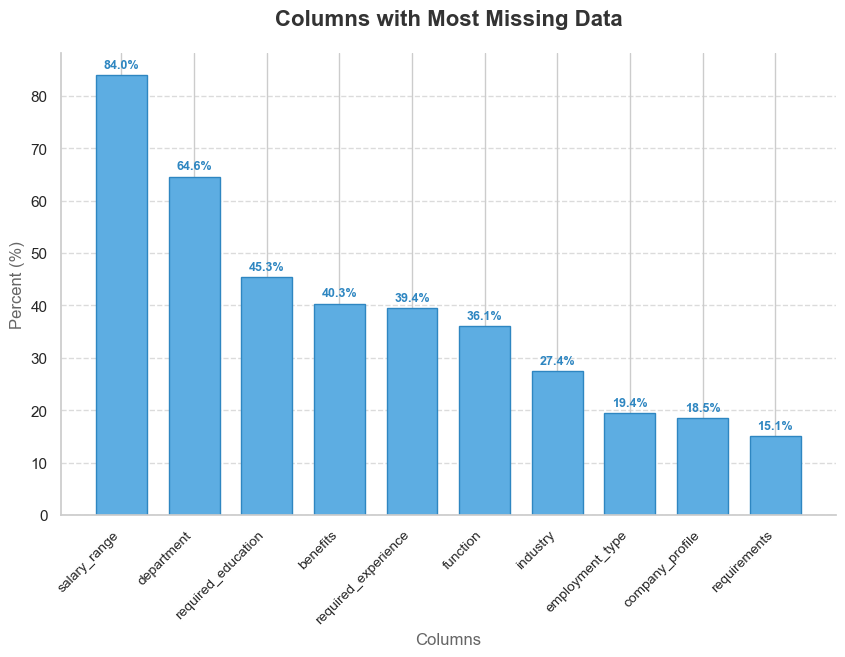

In [5]:
# 1. Create the figure and axis object explicitly
# Using a higher DPI here for the display preview
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 2. Plotting using the 'ax' object
data = missing_df['Percent (%)'].head(10)
bars = ax.bar(data.index, data.values, color='#5dade2', edgecolor='#2e86c1', width=0.7)

# 3. Customizing the 'ax' (The "Beautiful" part)
ax.set_title('Columns with Most Missing Data', fontsize=16, fontweight='bold', pad=20, loc='center', color='#333333')
ax.set_ylabel('Percent (%)', fontsize=12, color='#666666')
ax.set_xlabel('Columns', fontsize=12, color='#666666')

# Clean up the "chart junk"
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle horizontal gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.7, zorder=0)
ax.set_axisbelow(True)

# Refine ticks
ax.tick_params(axis='x', rotation=45, labelsize=10)
plt.xticks(ha='right') 

# Optional: Add data labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2e86c1')

# 4. Export high-resolution PNG
# bbox_inches='tight' ensures labels aren't cut off
fig.savefig('missing_data_chart_high_res.png', dpi=300, bbox_inches='tight', transparent=False, facecolor='white')

plt.show()

## Missing Data

The chart confirms `salary_range`, `department`, and `company_profile` as the most incomplete fields. These aren't just gaps to fill — they turn into fraud signals later in the analysis.

---

## Key Insight  

- Instead of treating missing values only as something to clean, they are used as indicators of suspicious listings.  

- Jobs with incomplete company information or missing key fields are more likely to be fraudulent.

In [6]:
# Summary statistics for numeric columns
print("Numeric Column Statistics:")
df.describe()

Numeric Column Statistics:


,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


## Quick Stats

Key numbers from the summary: only ~4.8% of posts are fake, 79% include a company logo, and just 4% are listed as remote. The dataset is heavily skewed toward real, on-site jobs with logos — anything that deviates from that pattern is worth investigating.

In [7]:
# Check target variable distribution (fraudulent: 0=real, 1=fake)
fraud_counts = df['fraudulent'].value_counts().reset_index()
fraud_counts.columns = ['fraudulent', 'count']
print("Fraudulent Job Distribution:")
fraud_counts

Fraudulent Job Distribution:


,fraudulent,count
0,0,17014
1,1,866


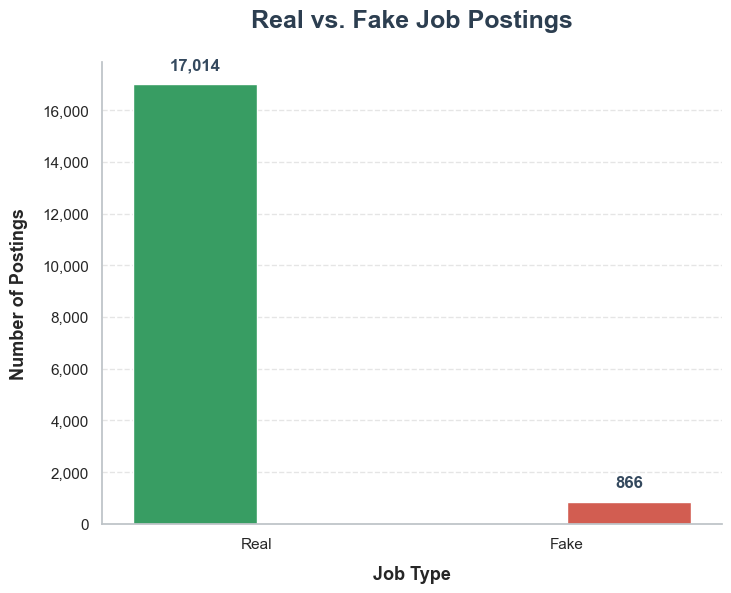

In [8]:
# 1. Initialize the figure and axis objects
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# 2. Plotting with Seaborn onto the 'ax'
# Adjusted keys to match numeric data: 0 = Real, 1 = Fake
colors = {0: '#27ae60', 1: '#e74c3c'} 

sns.barplot(data=fraud_counts, x='fraudulent', y='count', hue='fraudulent', palette=colors, ax=ax)

# Remove redundant legend
if ax.get_legend():
    ax.get_legend().remove()

# 3. Aesthetics & Styling
ax.set_title('Real vs. Fake Job Postings', fontsize=18, fontweight='bold', pad=25, color='#2c3e50')

# Optional: Rename the x-ticks if you want "Real" and "Fake" text instead of 0 and 1
ax.set_xticklabels(['Real', 'Fake'])

ax.set_xlabel('Job Type', fontsize=13, fontweight='semibold', labelpad=10)
ax.set_ylabel('Number of Postings', fontsize=13, fontweight='semibold', labelpad=10)

# Remove "Chart Junk"
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#bdc3c7')
ax.spines['bottom'].set_color('#bdc3c7')

# Add subtle horizontal grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Format Y-axis with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# 4. Add data labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 8), 
                    textcoords='offset points',
                    fontsize=12, fontweight='bold', color='#34495e')

# 5. Export high-resolution PNG
fig.savefig('real_vs_fake_jobs_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

## Real vs Fake Job Distribution  

Most job postings in the dataset are real, with only a small portion being fake (~4.8%).  

---

## Key Insight  

- Fake job listings are rare, but they are not random.  

- Even though they make up a small share, they follow consistent patterns — which makes them easier to identify when compared against real jobs.

---

## What This Means  

- The goal is not to find many fake jobs, but to **accurately identify the few that exist**.  

- This shifts the focus from volume to pattern detection — understanding what makes fake jobs different from real ones.

In [9]:
# Top 10 missing values summary
missing = df.isnull().sum().sort_values(ascending=False)

# Create DataFrame for top 10 missing columns
missing_df = pd.DataFrame({
    'column': missing.index[:10],
    'count': missing.values[:10]
})
print("Top 10 Missing Values:")
missing_df

Top 10 Missing Values:


,column,count
0,salary_range,15012
1,department,11547
2,required_education,8105
3,benefits,7212
4,required_experience,7050
5,function,6455
6,industry,4903
7,employment_type,3471
8,company_profile,3308
9,requirements,2696


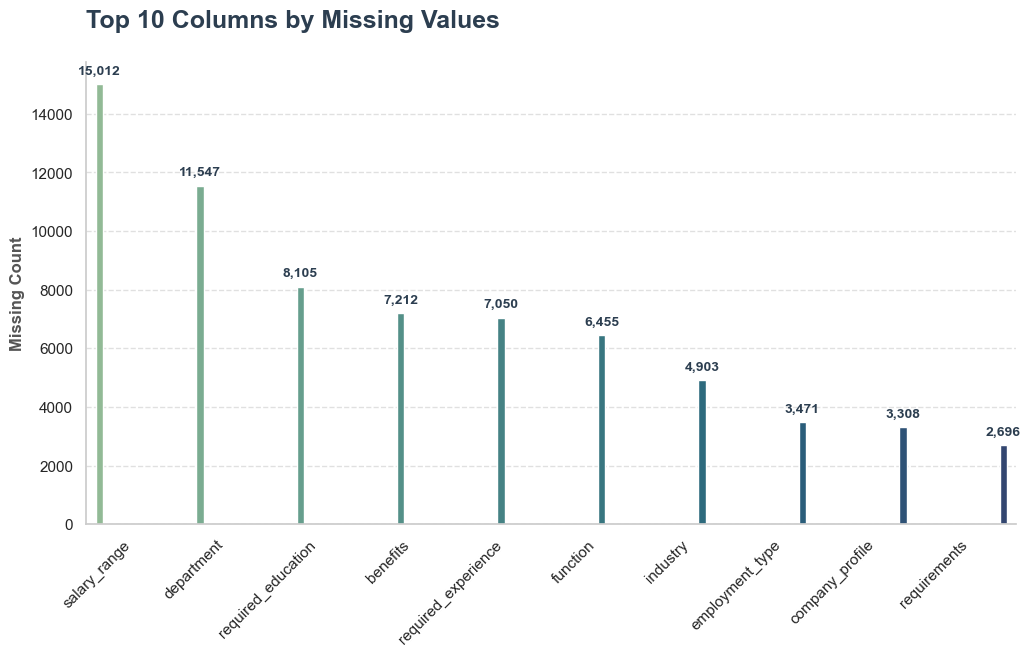

In [10]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# Removed legend=False from here to avoid the AttributeError
sns.barplot(
    data=missing_df.head(10), 
    x='column', 
    y='count', 
    hue='column', 
    palette='crest', 
    ax=ax
)

# 3. Remove the legend manually from the axis
if ax.get_legend():
    ax.get_legend().remove()

# 4. Aesthetics & Styling
ax.set_title('Top 10 Columns by Missing Values', fontsize=18, fontweight='bold', pad=25, loc='left', color='#2c3e50')
ax.set_ylabel('Missing Count', fontsize=12, fontweight='semibold', color='#555555')
ax.set_xlabel('', fontsize=12)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Rotate x-ticks and align them to the end of the tick
ax.tick_params(axis='x', rotation=45)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment('right')

# Add subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)

# 5. Add data labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#2c3e50')

# 6. Export high-resolution PNG
fig.savefig('top_missing_columns_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

<a id="data-cleaning"></a>
# Top 10 Columns with Missing Values

- This chart shows which columns in the dataset have the most missing values.  
- It helps identify areas that need data cleaning or imputation before analysis.  
- Columns like **salary_range** and **department** have the highest number of missing values.  
- These gaps indicate incomplete or inconsistent information in those fields.

---


In [11]:
# Fill missing text columns with "Unknown"
text_cols = ['salary_range', 'company_profile', 'benefits', 'requirements', 'description', 'department']
df[text_cols] = df[text_cols].fillna('Unknown')
print("Missing text columns filled with 'Unknown'")

Missing text columns filled with 'Unknown'


In [12]:
# Fill missing categorical columns with 'Unknown'
cat_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function', 'location']
df[cat_cols] = df[cat_cols].fillna('Unknown')
print("Missing categorical columns filled with 'Unknown'")

Missing categorical columns filled with 'Unknown'


In [13]:
# Create feature: flag for missing company_profile (1=missing, 0=present)
df['company_missing'] = df['company_profile'].apply(lambda x: 1 if x == 'Unknown' else 0)
print("'company_missing' feature created")

'company_missing' feature created


In [14]:
# Review changes in text columns + new feature
print("=" * 80)
print(df[text_cols + ['company_missing']].head())
print("=" * 80)

  salary_range                                    company_profile  \
0      Unknown  We're Food52, and we've created a groundbreaki...   
1      Unknown  90 Seconds, the worlds Cloud Video Production ...   
2      Unknown  Valor Services provides Workforce Solutions th...   
3      Unknown  Our passion for improving quality of life thro...   
4      Unknown  SpotSource Solutions LLC is a Global Human Cap...   

                                            benefits  \
0                                            Unknown   
1  What you will get from usThrough being part of...   
2                                            Unknown   
3  Our culture is anything but corporate—we have ...   
4                              Full Benefits Offered   

                                        requirements  \
0  Experience with content management systems a m...   
1  What we expect from you:Your key responsibilit...   
2  Implement pre-commissioning and commissioning ...   
3  EDUCATION: Bachelor’s

## Data Preparation  

To make the data usable for analysis, missing text fields were filled with "Unknown".  

More importantly, a new flag was created:

- `company_missing` → indicates whether company profile is missing  

---

## Why This Matters  

- Missing company information is one of the strongest signals of a suspicious job posting.  

- Instead of treating missing data only as a cleaning step, it is turned into a feature that helps identify fake listings.

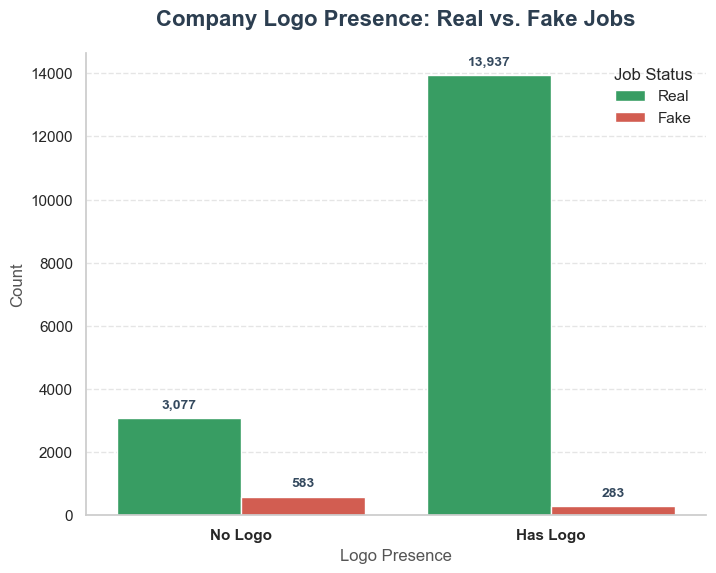

In [15]:
# 1. Initialize figure and axis
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# Using specific colors for consistency: Green for Real, Red for Fake
colors = {0: '#27ae60', 1: '#e74c3c'}
sns.countplot(data=df, x='has_company_logo', hue='fraudulent', palette=colors, ax=ax)

# 3. Aesthetics & Styling
ax.set_title('Company Logo Presence: Real vs. Fake Jobs', fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

# Update X-axis labels using the axis object
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Logo', 'Has Logo'], fontsize=11, fontweight='semibold')

ax.set_xlabel('Logo Presence', fontsize=12, color='#555555')
ax.set_ylabel('Count', fontsize=12, color='#555555')

# Customizing the Legend via the axis object
legend_labels = ['Real', 'Fake']
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, legend_labels, title='Job Status', frameon=False, loc='upper right')

# Remove "Chart Junk"
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle grid and set it behind bars
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 4. Add data labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#34495e')

# 5. Export high-resolution PNG
fig.savefig('company_logo_comparison_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

## Company Logo vs Fraud  

This comparison shows a clear difference between real and fake job postings.

---

## Key Insight  

- Most real job postings include a company logo  
- Fake job postings are much more likely to have no logo  
- Missing logo is a strong warning sign of a suspicious listing  

---

## What This Means  

- Company logo is not just a visual element — it acts as a trust signal.  

- Jobs without a logo should be treated with higher risk and can be flagged early in the screening process.

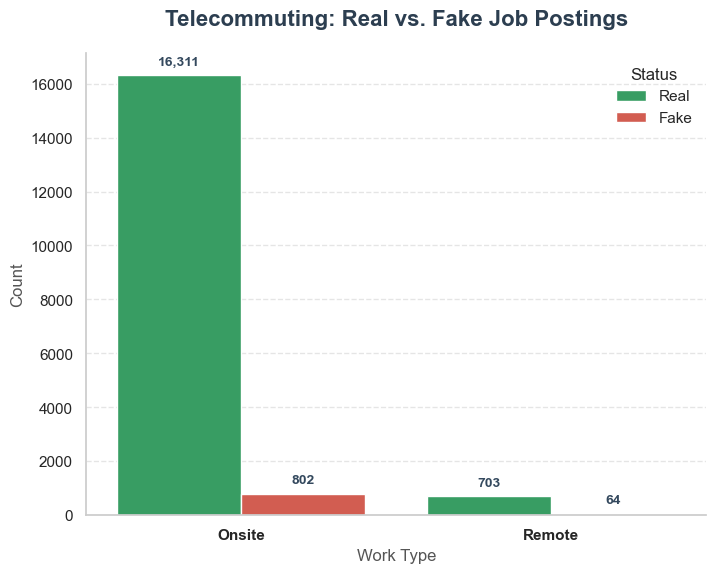

In [16]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# Using consistent green/red mapping (0=Real, 1=Fake)
colors = {0: '#27ae60', 1: '#e74c3c'}
sns.countplot(data=df, x='telecommuting', hue='fraudulent', palette=colors, ax=ax)

# 3. Aesthetics & Styling
ax.set_title('Telecommuting: Real vs. Fake Job Postings', fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

# Update X-axis labels to be descriptive
ax.set_xticks([0, 1])
ax.set_xticklabels(['Onsite', 'Remote'], fontsize=11, fontweight='semibold')

ax.set_xlabel('Work Type', fontsize=12, color='#555555')
ax.set_ylabel('Count', fontsize=12, color='#555555')

# Refine Legend
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Real', 'Fake'], title='Status', frameon=False, loc='upper right')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle Y-axis grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 4. Add data labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#34495e')

# 5. Export high-resolution PNG
fig.savefig('telecommuting_comparison_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

## Remote Jobs vs Fraud  

This comparison shows how remote job postings differ from on-site roles when it comes to fraud.

---

## Key Insight  

- Most job postings are on-site and real  
- Fake job listings are more likely to appear in remote roles compared to on-site jobs  

Remote job listings carry slightly higher risk and should be monitored more closely  

---

## What This Means  

- Remote jobs are attractive and easier to misuse, making them a common choice for fraudulent postings.  
- Remote listings should be treated as a higher-risk category during screening.

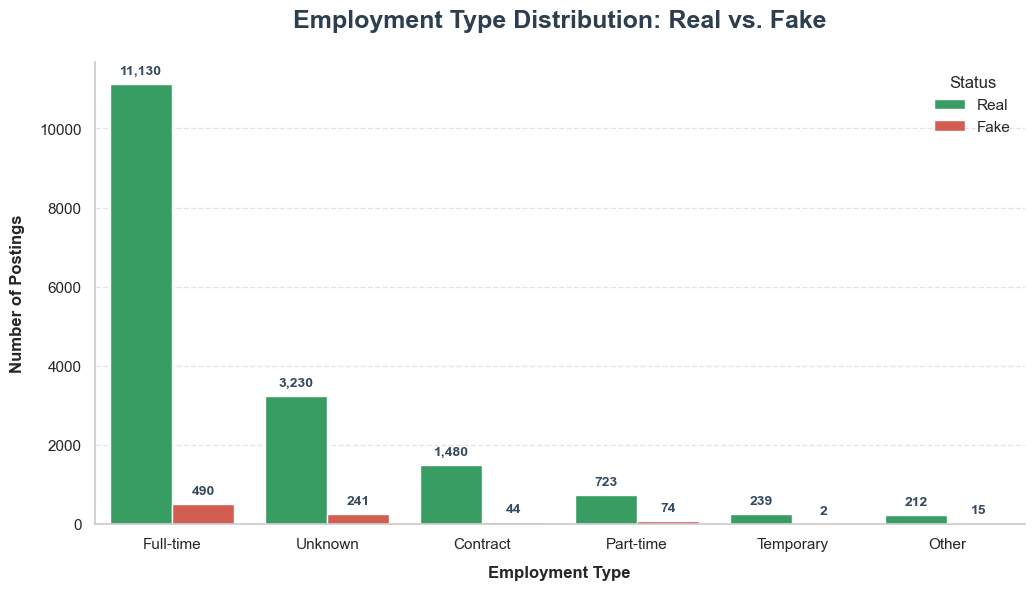

In [17]:
# 1. Initialize figure and axis
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# 2. Prepare data and plot
# Filter for top 6 employment types
top_types = df['employment_type'].value_counts().nlargest(6).index
filtered_df = df[df['employment_type'].isin(top_types)]

# Define consistent color mapping (0: Real/Green, 1: Fake/Red)
colors = {0: '#27ae60', 1: '#e74c3c'}

sns.countplot(
    data=filtered_df, 
    x='employment_type', 
    hue='fraudulent', 
    palette=colors, 
    order=top_types,
    ax=ax
)

# 3. Aesthetics & Styling
ax.set_title('Employment Type Distribution: Real vs. Fake', 
             fontsize=18, fontweight='bold', pad=25, loc='center', color='#2c3e50')
ax.set_xlabel('Employment Type', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel('Number of Postings', fontsize=12, fontweight='semibold', labelpad=10)

# Clean up visual noise
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Refine Legend via the axis object
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Real', 'Fake'], title='Status', frameon=False, loc='upper right')

# Add subtle horizontal grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 4. Add data labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#34495e')

# 5. Export high-resolution PNG
fig.savefig('employment_type_distribution_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

## Employment Type vs Fraud  

This comparison shows how job types differ across real and fake postings.

---

## Key Insight  

- Most job postings are full-time and real  
- Fake job listings appear across multiple categories, especially under full-time and unknown types  

Employment type alone is not a strong indicator of fraud  

---

## What This Means  

- Unlike other signals, employment type does not clearly separate fake jobs from real ones.  

- It should not be used as a primary factor when detecting suspicious listings.

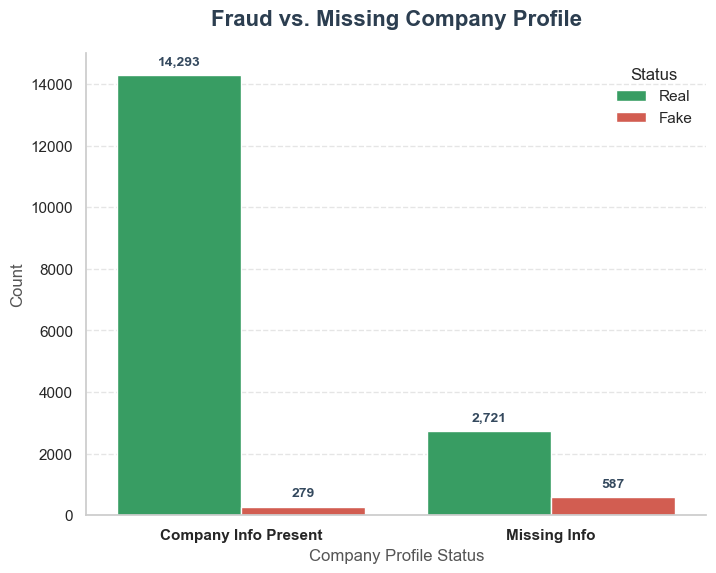

In [18]:
# 1. Initialize figure and axis
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# Maintaining consistent green/red color mapping
colors = {0: '#27ae60', 1: '#e74c3c'}
sns.countplot(data=df, x='company_missing', hue='fraudulent', palette=colors, ax=ax)

# 3. Aesthetics & Styling
ax.set_title('Fraud vs. Missing Company Profile', fontsize=16, fontweight='bold', pad=20, color='#2c3e50')

# Update X-axis labels using the axis object
ax.set_xticks([0, 1])
ax.set_xticklabels(['Company Info Present', 'Missing Info'], fontsize=11, fontweight='semibold')

ax.set_xlabel('Company Profile Status', fontsize=12, color='#555555')
ax.set_ylabel('Count', fontsize=12, color='#555555')

# Refine Legend
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['Real', 'Fake'], title='Status', frameon=False, loc='upper right')

# Clean up visual "noise"
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 4. Add data labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold', color='#34495e')

# 5. Export high-resolution PNG
fig.savefig('missing_company_profile_fraud_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

## Company Profile Missing vs Fraud  

This is one of the strongest differences between real and fake job postings.

---

## Key Insight  

- Most real job postings include company information  
- Fake job postings are far more likely to have missing company details  

Missing company profile is a strong indicator of a suspicious listing  

---

## What This Means  

- Company information acts as a trust signal.  

- Jobs without company details should be treated as high-risk and flagged early in the screening process.

In [19]:
# Create text length features for ML modeling
df['desc_length'] = df['description'].apply(lambda x: len(str(x)))
df['req_length'] = df['requirements'].apply(lambda x: len(str(x)))
print("Text length features created: desc_length, req_length")

Text length features created: desc_length, req_length


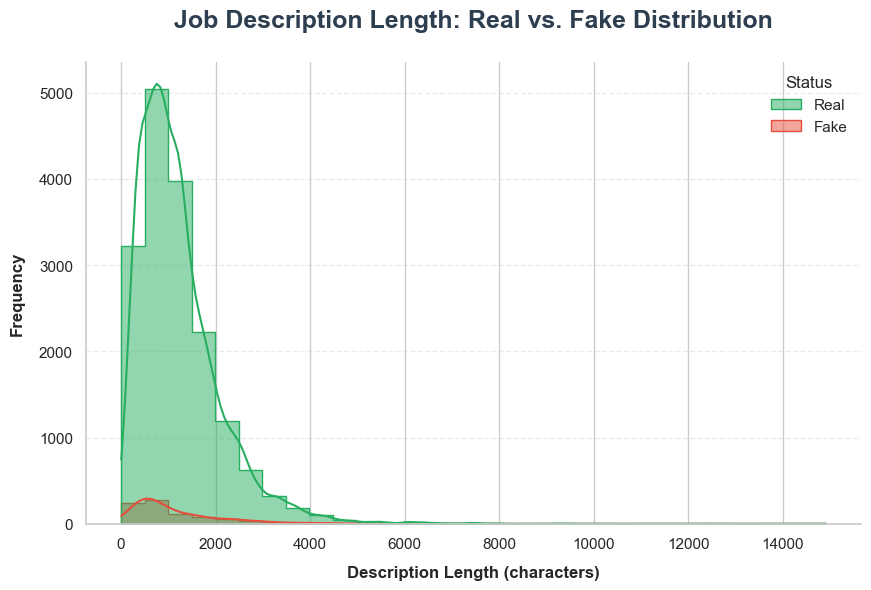

In [20]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# Consistent palette: 0 is Real (Green), 1 is Fake (Red)
colors = {0: '#27ae60', 1: '#e74c3c'}

sns.histplot(
    data=df, 
    x='desc_length', 
    hue='fraudulent', 
    bins=30, 
    kde=True, 
    palette=colors, 
    ax=ax,
    alpha=0.5,
    element="step"
)

# 3. FIX: Manually force the legend labels
# We grab the handles created by seaborn and assign our specific strings
handles = ax.get_legend().legend_handles if ax.get_legend() else None
ax.legend(handles=handles, labels=['Real', 'Fake'], title='Status', frameon=False, loc='upper right')

# 4. Aesthetics & Styling
ax.set_title('Job Description Length: Real vs. Fake Distribution', 
             fontsize=18, fontweight='bold', pad=25, loc='center', color='#2c3e50')
ax.set_xlabel('Description Length (characters)', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel('Frequency', fontsize=12, fontweight='semibold', labelpad=10)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# 5. Export high-resolution PNG
fig.savefig('description_length_fixed_legend.png', dpi=300, bbox_inches='tight')

plt.show()

## Job Description & Requirements vs Fraud  

This comparison highlights how content quality differs between real and fake job postings.

---

## Key Insight  

- Real job postings usually include longer and more detailed descriptions and requirements  
- Fake job postings tend to have short, vague, or missing content  

Lack of detailed content is a strong warning sign of a suspicious listing  

---

## What This Means  

Writing clear job descriptions and requirements takes effort, which real companies usually invest in.  

Jobs with very short or incomplete content should be treated as higher risk during screening.

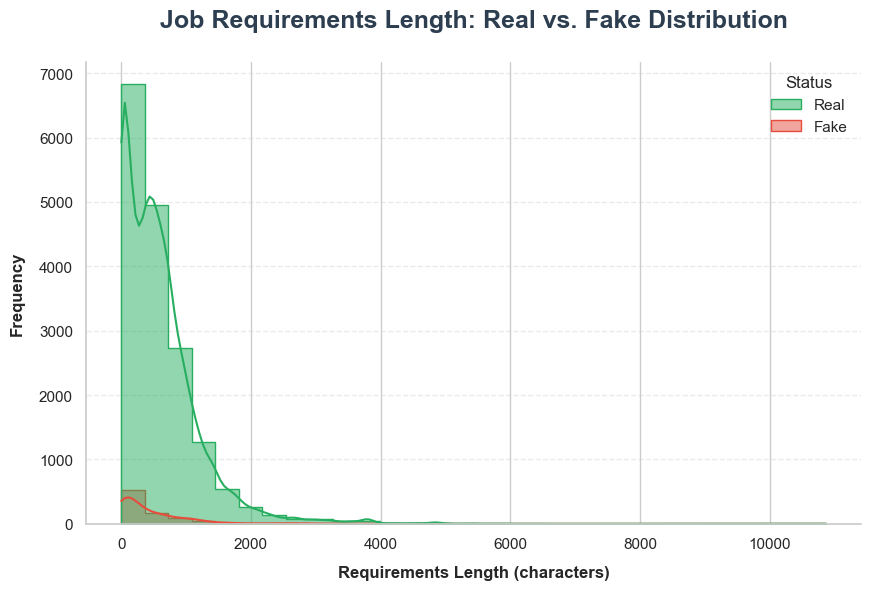

In [21]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 2. Plot requirements length distribution
colors = {0: '#27ae60', 1: '#e74c3c'}

sns.histplot(
    data=df, 
    x='req_length', 
    hue='fraudulent', 
    bins=30, 
    kde=True, 
    palette=colors, 
    ax=ax,
    alpha=0.5,
    element="step"
)

# 3. Fix legend labels
handles = ax.get_legend().legend_handles if ax.get_legend() else None
ax.legend(handles=handles, labels=['Real', 'Fake'], title='Status', frameon=False, loc='upper right')

# 4. Aesthetics
ax.set_title('Job Requirements Length: Real vs. Fake Distribution', 
             fontsize=18, fontweight='bold', pad=25, loc='center', color='#2c3e50')
ax.set_xlabel('Requirements Length (characters)', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel('Frequency', fontsize=12, fontweight='semibold', labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# 5. Export
fig.savefig('requirements_length_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

## Requirements Length vs Fraud

Same pattern as descriptions — real job posts list detailed requirements, fake ones keep it short or skip it entirely. Another signal that content effort separates real employers from scammers.

In [22]:
# Feature: Word count in company profile
df['profile_wordcount'] = df['company_profile'].apply(lambda x: len(str(x).split()))

# Compare average word count by fraud status
avg_profile_words = df.groupby('fraudulent')['profile_wordcount'].mean()
print("Average company profile words (Real vs Fake):\n", avg_profile_words)

Average company profile words (Real vs Fake):
 fraudulent
0    95.810450
1    32.386836
Name: profile_wordcount, dtype: float64


In [23]:
# Feature: Flag suspicious keywords in description
keywords = ['easy money', 'work from home', 'urgent', 'fast cash', 'investment']
df['suspicious_desc'] = df['description'].apply(
    lambda x: int(any(word in str(x).lower() for word in keywords))
)

print("Suspicious keywords % (Real vs Fake):")
print(df.groupby('fraudulent')['suspicious_desc'].mean())

Suspicious keywords % (Real vs Fake):
fraudulent
0    0.042083
1    0.125866
Name: suspicious_desc, dtype: float64


## Company Profile Depth & Suspicious Keywords  

This analysis highlights how content quality and language differ between real and fake job postings.

---

## Key Insights  

- Real job postings have **~96 words** in company profiles on average  
- Fake job postings have only **~32 words**, showing limited company information  

Short company profiles are a strong warning sign  

---

- Around **12% of fake job postings** contain suspicious keywords  
- Only **~4% of real jobs** use similar language  

Words like “easy money”, “fast cash”, and “urgent” appear more often in fake listings  

---

## What This Means  

- Real companies invest effort in detailed profiles and clear communication.  
- Fake job postings rely on short content and attention-grabbing keywords to attract users quickly.

In [24]:
# Feature: Flag if salary range was provided (1=provided, 0=Unknown)
df['has_salary_range'] = df['salary_range'].apply(lambda x: 0 if x == 'Unknown' else 1)
print("'has_salary_range' feature created")

'has_salary_range' feature created


In [25]:
# Calculate fraud rate by salary range presence
salary_fraud_rate = df.groupby('has_salary_range')['fraudulent'].mean().reset_index()
print("Fraud rate by salary presence:")
salary_fraud_rate

Fraud rate by salary presence:


,has_salary_range,fraudulent
0,0,0.042832
1,1,0.077755


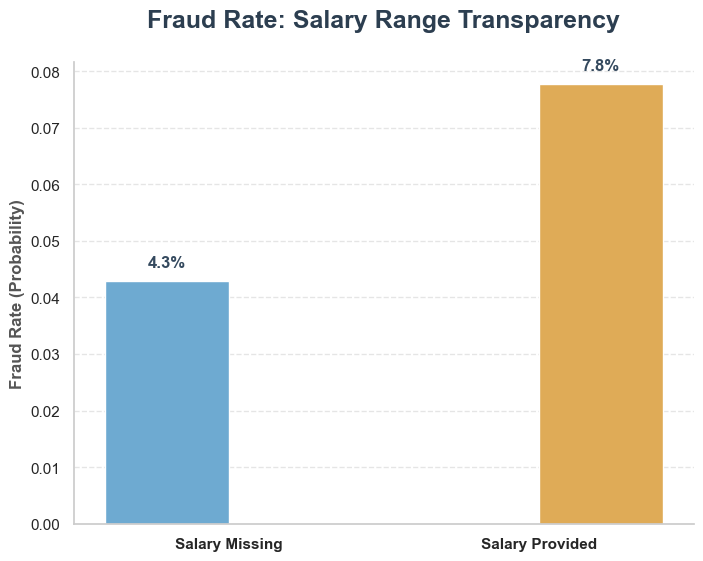

In [26]:
# 1. Initialize figure and axis
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# Using consistent colors: Green for lower risk, Red for higher risk
# 0 = Salary Missing, 1 = Salary Provided
colors = {0: '#5dade2', 1: '#f5b041'} 

sns.barplot(
    data=salary_fraud_rate, 
    x='has_salary_range', 
    y='fraudulent', 
    hue='has_salary_range', 
    palette=colors, 
    ax=ax
)

# 3. Aesthetics & Styling
ax.set_title('Fraud Rate: Salary Range Transparency', fontsize=18, fontweight='bold', pad=25, loc='center', color='#2c3e50')

# Update X-axis labels
ax.set_xticks([0, 1])
ax.set_xticklabels(['Salary Missing', 'Salary Provided'], fontsize=11, fontweight='semibold')

ax.set_xlabel('', fontsize=12)
ax.set_ylabel('Fraud Rate (Probability)', fontsize=12, fontweight='semibold', color='#555555')

# Remove redundant legend (X-axis labels cover this)
if ax.get_legend():
    ax.get_legend().remove()

# Clean up visual noise
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 4. Add data labels as Percentages
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=12, fontweight='bold', color='#34495e')

# 5. Export high-resolution PNG
fig.savefig('salary_transparency_fraud_rate.png', dpi=300, bbox_inches='tight')

plt.show()

## Salary Information vs Fraud  

This comparison shows how salary details relate to real and fake job postings.

---

## Key Insight  

- Job postings that include salary information show a slightly higher fraud rate  
- Some fake job listings use salary details to appear more convincing  

Salary presence alone is not a reliable indicator of a genuine job  

---

## What This Means  

- Unlike other signals, salary information does not clearly separate fake jobs from real ones.  
- It should not be used as a primary factor when detecting suspicious listings.

In [27]:
# Create missing info feature flags (0=missing, 1=present)
df['has_location'] = df['location'].apply(lambda x: 0 if x == 'Unknown' else 1)
df['has_education'] = df['required_education'].apply(lambda x: 0 if x == 'Unknown' else 1)
df['has_industry'] = df['industry'].apply(lambda x: 0 if x == 'Unknown' else 1)

print("Missing info flags created")

Missing info flags created


In [28]:
# Create 'missing_info_score' (0=most vague, 5=complete info)
df['missing_info_score'] = (
    df['has_company_logo'] +
    df['has_location'] +
    df['has_salary_range'] +
    df['has_education'] +
    df['has_industry']
)
print("'missing_info_score' created (0-5 scale)")

'missing_info_score' created (0-5 scale)


In [29]:
# Calculate fraud rate by missing info score
missing_info_fraud_rate = df.groupby('missing_info_score')['fraudulent'].mean().reset_index()
print("Fraud rate by missing info score:")
missing_info_fraud_rate

Fraud rate by missing info score:


,missing_info_score,fraudulent
0,0,0.476190
1,1,0.131115
2,2,0.060837
3,3,0.026412
4,4,0.034249
5,5,0.050435


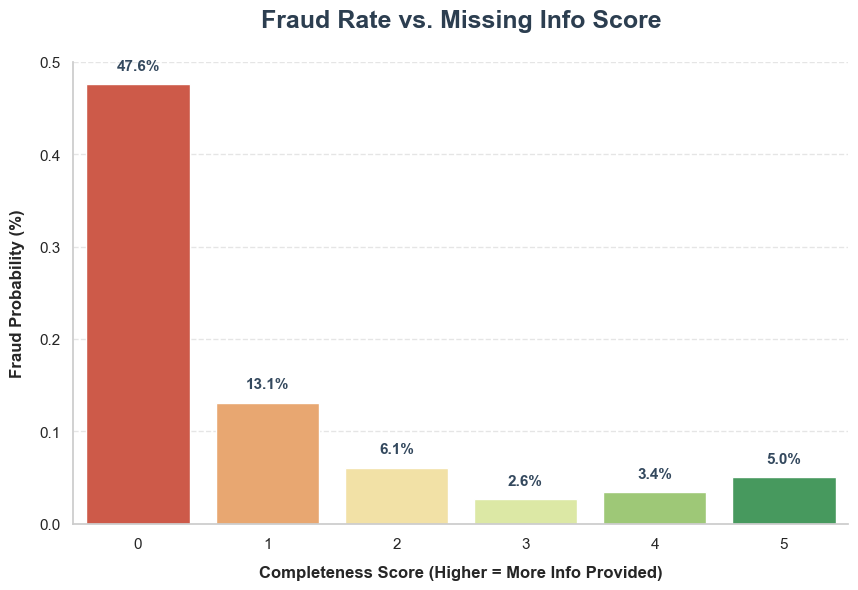

In [30]:
# 1. Initialize figure and axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# 'RdYlGn' (Red-Yellow-Green) is great here: 
# It visually links 'Vague/Missing' to Red and 'Detailed' to Green
sns.barplot(
    data=missing_info_fraud_rate, 
    x='missing_info_score', 
    y='fraudulent', 
    palette='RdYlGn', 
    ax=ax
)

# 3. Aesthetics & Styling
ax.set_title('Fraud Rate vs. Missing Info Score', 
             fontsize=18, fontweight='bold', pad=25, loc='center', color='#2c3e50')

ax.set_xlabel('Completeness Score (Higher = More Info Provided)', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel('Fraud Probability (%)', fontsize=12, fontweight='semibold', labelpad=10)

# Clean up visual noise
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle grid
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# 4. Add data labels as Percentages
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='#34495e')

# 5. Export high-resolution PNG
fig.savefig('completeness_vs_fraud_rate.png', dpi=300, bbox_inches='tight')

plt.show()

## Missing Information Score vs Fraud  

This combines multiple signals into a single score based on how much information a job posting provides.

---

## Key Insight  

- Jobs with very little information (low score) have the highest fraud rate  
- As more details are provided, the fraud rate drops sharply  

Incomplete job postings are significantly more likely to be fake  

---

## What This Means  

- Missing information is not just a data issue — it is a strong fraud signal.  

- A simple scoring system based on content completeness can effectively identify high-risk job postings early.

In [31]:
# Top 10 industries fraud analysis (excluding Unknown)
top_10_industries = df[df['industry'] != 'Unknown']['industry'].value_counts().nlargest(10).index

# Filter and calculate fraud stats
df_top_industry = df[df['industry'].isin(top_10_industries)]
print("Fraud rate by Top 10 Industries:")
df_top_industry.groupby('industry')['fraudulent'].agg(['count', 'sum', 'mean'])

Fraud rate by Top 10 Industries:


,count,sum,mean
industry,,,
Computer Software,1376,5,0.003634
Consumer Services,358,24,0.067039
Education Management,822,0,0.000000
Financial Services,779,35,0.044929
Hospital & Health Care,497,51,0.102616
Information Technology and Services,1734,32,0.018454
Internet,1062,0,0.000000
Marketing and Advertising,828,45,0.054348
Oil & Energy,287,109,0.379791


In [32]:
# Calculate and sort industry fraud rates (highest first)
industry_fraud_rate = df_top_industry.groupby('industry')['fraudulent'].mean().reset_index()
industry_fraud_rate = industry_fraud_rate.sort_values(by='fraudulent', ascending=False)

print("Riskiest Industries by Fraud Rate:")
industry_fraud_rate

Riskiest Industries by Fraud Rate:


,industry,fraudulent
8,Oil & Energy,0.379791
4,Hospital & Health Care,0.102616
9,Telecommunications,0.076023
1,Consumer Services,0.067039
7,Marketing and Advertising,0.054348
3,Financial Services,0.044929
5,Information Technology and Services,0.018454
0,Computer Software,0.003634
2,Education Management,0.000000
6,Internet,0.000000


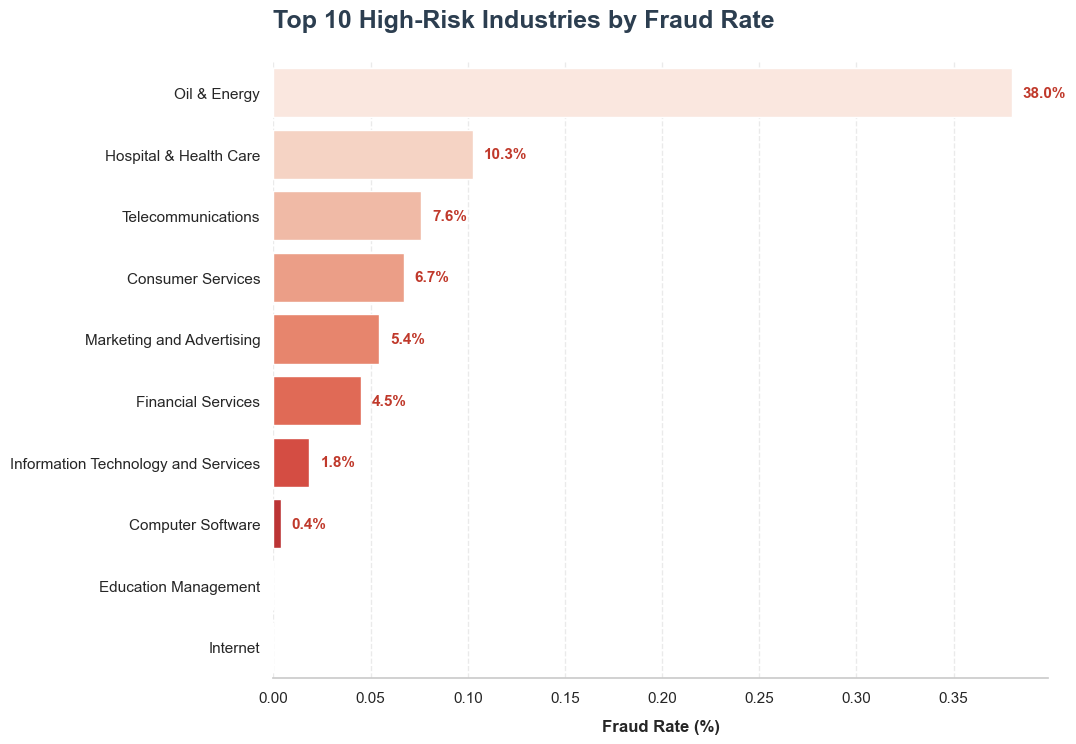

In [33]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

# 2. Plotting with Seaborn onto 'ax'
# Using 'Reds' to highlight high-risk fraud rates
sns.barplot(
    data=industry_fraud_rate, 
    x='fraudulent', 
    y='industry', 
    hue='industry',
    dodge=False,
    palette='Reds', 
    ax=ax
)

# 3. FIX: Remove the legend manually from the axis object
if ax.get_legend():
    ax.get_legend().remove()

# 4. Aesthetics & Styling
ax.set_title('Top 10 High-Risk Industries by Fraud Rate', 
             fontsize=18, fontweight='bold', pad=25, loc='left', color='#2c3e50')

ax.set_xlabel('Fraud Rate (%)', fontsize=12, fontweight='semibold', labelpad=10)
ax.set_ylabel('', fontsize=12) 

# Clean up spines (Removing left spine for a cleaner horizontal look)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.spines['left'].set_visible(False)

# Add subtle vertical gridlines
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# 5. Add data labels as Percentages at the end of each bar
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1%}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(8, 0), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold', color='#c0392b')

# 6. Export high-resolution PNG
fig.savefig('industry_fraud_rate_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

## Industry-Level Observation  

- Some industries show higher fraud rates, such as Oil & Energy and Healthcare.  

- However, the number of job postings varies across industries, which makes these patterns less stable.  

- Industry alone is not a reliable indicator and should only be used as a supporting signal alongside stronger factors like missing information and content quality.

### Final Check: Adding Up All the Red Flags

We’ve seen many warning signs — missing logo, no profile, no salary, and so on. But what happens when one job post has all of them together? So let's made a chart to see how the chance of fraud changes as the number of red flags increases.

In [34]:
# Stack red flags using AND logic to measure combined fraud risk
risk_data = [
    {'Risk Factor': 'All Jobs (Baseline)',
     'Fraud Rate': df['fraudulent'].mean()},
    
    {'Risk Factor': 'No Company Logo',
     'Fraud Rate': df[df['has_company_logo'] == 0]['fraudulent'].mean()},
    
    {'Risk Factor': 'No Logo AND No Profile',
     'Fraud Rate': df[(df['has_company_logo'] == 0) & (df['company_missing'] == 1)]['fraudulent'].mean()},
    
    {'Risk Factor': 'No Logo AND No Profile AND Short Description',
     'Fraud Rate': df[(df['has_company_logo'] == 0) & (df['company_missing'] == 1) & (df['desc_length'] < 500)]['fraudulent'].mean()},
    
    {'Risk Factor': 'No Logo AND No Profile AND Short Desc AND Suspicious Keywords',
     'Fraud Rate': df[(df['has_company_logo'] == 0) & (df['company_missing'] == 1) & (df['desc_length'] < 500) & (df['suspicious_desc'] == 1)]['fraudulent'].mean()}
]

risk_df = pd.DataFrame(risk_data)
print("Red Flag Risk Analysis:")
risk_df

Red Flag Risk Analysis:


,Risk Factor,Fraud Rate
0,All Jobs (Baseline),0.048434
1,No Company Logo,0.159290
2,No Logo AND No Profile,0.218154
3,No Logo AND No Profile AND Short Description,0.266862
4,No Logo AND No Profile AND Short Desc AND Susp...,0.666667


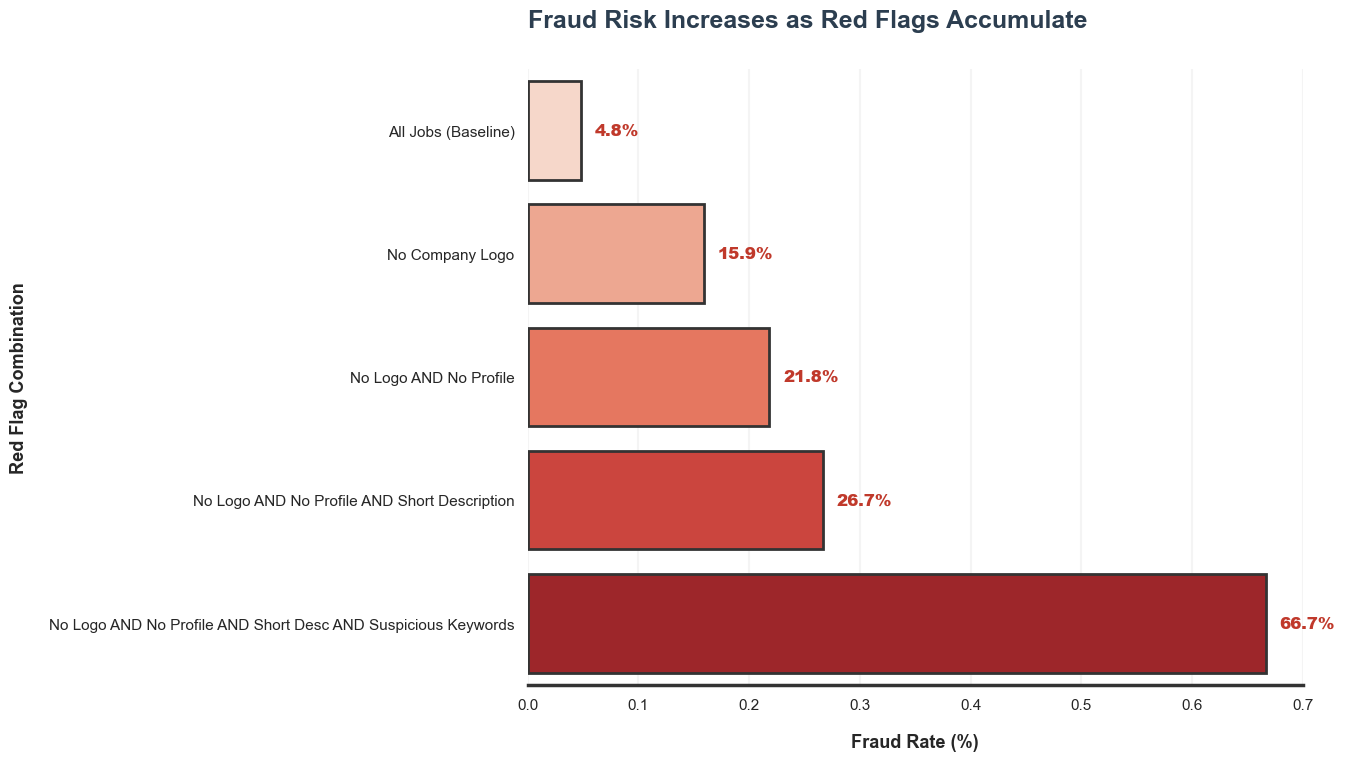

In [35]:
# 1. Initialize the figure and axis
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

# 2. Plotting with "Bolder" properties
# Higher 'edgecolor' and 'linewidth' make the bars pop
sns.barplot(
    data=risk_df, 
    x='Fraud Rate', 
    y='Risk Factor',
    hue='Risk Factor',
    dodge=False,
    palette='Reds', 
    ax=ax,
    edgecolor='#333333',
    linewidth=2      # Thicker bar borders
)

# 3. Remove the legend manually (Avoids version-specific errors)
if ax.get_legend():
    ax.get_legend().remove()

# 4. Bold Aesthetics & Styling
ax.set_title('Fraud Risk Increases as Red Flags Accumulate', 
             fontsize=18, fontweight='bold', pad=30, loc='left', color='#2c3e50')

ax.set_xlabel('Fraud Rate (%)', fontsize=13, fontweight='bold', labelpad=15)
ax.set_ylabel('Red Flag Combination', fontsize=13, fontweight='bold', labelpad=15)

# Thicken the Spines (Axis lines)
ax.spines['bottom'].set_linewidth(2.5)
ax.spines['bottom'].set_color('#333333')
ax.spines['left'].set_visible(False) # Cleaner look for horizontal labels
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Thicker Vertical Gridlines
ax.xaxis.grid(True, linestyle='-', alpha=0.2, linewidth=1.5, zorder=0)
ax.set_axisbelow(True)

# 5. Add Bold Data Labels (Percentages)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1%}', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(10, 0), 
                    textcoords='offset points',
                    fontsize=12, fontweight='black', color='#c0392b')

# 6. Export high-resolution PNG
fig.savefig('risk_factor_bold_high_res.png', dpi=300, bbox_inches='tight')

plt.show()

## Red Flag Combination vs Fraud Risk  

This analysis shows how fraud risk increases as multiple warning signs appear together.

---

## Key Insight  

- Baseline fraud rate is low across all jobs  
- Missing a single detail (like logo) increases risk  
- Combining multiple missing signals increases fraud risk significantly  
- Jobs missing both logo and company profile show the highest fraud rate  

Fraud risk rises sharply as red flags accumulate  

---

## What This Means  

- Individual signals are useful, but their real power comes when combined.  
- A simple rule-based system using multiple red flags can effectively identify high-risk job postings without complex models.


---

---


# Suspicious Pattern Detection

Fake job postings follow a few clear and repeatable patterns. These patterns are consistent across the dataset and form the basis of detection logic.

**Missing Company Information**
Fake listings almost never include a company logo or profile. When a post hides who's behind it, the fraud rate jumps significantly. This is the single strongest signal in the data.

**Short or Vague Descriptions**
Real job posts average much longer descriptions than fake ones. Scammers don't put effort into writing detailed role descriptions, requirements, or company backgrounds. Short and generic text is a red flag.

**Suspicious Keywords**
Salary information behaves differently from other signals. Some fake listings include salary details to appear more legitimate, making this a less reliable indicator on its own.

**Salary Info Can Be Misleading**
This one is counterintuitive. Posts that include salary details actually have a slightly higher fraud rate. Some scammers add fake salary ranges to make the listing look more convincing. So salary presence alone doesn't mean a post is safe.

**Red Flags Stack Up**
When a post is missing multiple details at once — no logo, no profile, no salary, no education requirement — the fraud rate climbs steeply. A post missing one thing might be fine. A post missing four things is almost certainly fake. A post missing multiple key details has a significantly higher probability of being fake.

---

# Trust Score System

Based on the patterns above, a simple scoring system can flag risky job listings before they go live.

Each new post gets checked on five signals:

| Signal | Red Flag Condition | Points |
|--------|-------------------|--------|
| Company logo | Missing | +1 |
| Company profile | Missing or blank | +1 |
| Description length | Below a set character threshold | +1 |
| Suspicious keywords | Contains 2+ flagged words | +1 |
| Missing info score | 3+ fields left blank (salary, education, industry, etc.) | +1 |

**How to read the score:**

- **0–1** → Low risk. Post goes live immediately.
- **2–3** → Medium risk. Flag for quick review or show a warning to users.
- **4–5** → High risk. Hold for manual review before publishing.

This kind of check takes milliseconds to run on each new listing. It catches most fake posts without creating friction for real employers who fill in their details properly.

---

# Business Use Case

This approach plugs directly into a job platform's posting workflow.

**For the platform:** When a new job is submitted, the system calculates a Trust Score in the background. Low-risk posts go live instantly. High-risk posts get held for review. This cuts down on fake listings without adding extra steps for legitimate employers.

**For job seekers:** Fewer scam posts means less wasted time and more confidence in the platform. Users don't need to see the score — they just see a cleaner, more trustworthy feed.

**For companies posting jobs:** Real employers who fill in complete details won't be affected at all. Their posts clear the score check automatically. The system only catches the posts that look suspicious — which is exactly the point.

The implementation is lightweight — no machine learning model needed, no complex infrastructure. Just a scoring function that runs on every new submission.

---

# Recommendations

Four things a job platform should do based on this data:

**1. Require company identity fields**
Make company name, logo upload, and profile description mandatory. This single change blocks the most common pattern in fake posts — hiding who's behind the listing.

**2. Set minimum content standards**
Add a minimum character count for job descriptions and requirements. Fake posts are almost always shorter than real ones. A floor of 200-300 characters for the description would filter out the laziest scams.

**3. Flag suspicious keyword combinations**
Build a simple keyword scanner that checks for known red-flag phrases. One keyword alone isn't enough to flag a post — but two or three together should trigger a review.

**4. Focus on content completeness over category**
Fraud patterns are more strongly linked to missing information and weak content than to specific industries. Prioritize signals like missing company details and vague descriptions over category-based filtering.

---

# Conclusion

The data shows a consistent pattern: fake job postings lack transparency, structure, and detail.

These patterns are consistent enough to catch most fakes with a simple scoring system — no machine learning required. The Trust Score approach described here is lightweight, easy to implement, and doesn't slow down legitimate employers.

For any platform dealing with job posting fraud, this analysis provides a ready-to-use framework: check the signals, calculate a score, flag the risky ones.

---